# Fortune-500-Inclusion — a quantitative teardown 🔬
### Market-model CAR by bucket · added−dropped Welch *t* + a placebo non-event-window null · the [0,0]-vs-[0,+2] window split · a 1-day-lag tradable variant + costs · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Attention_effect%3F: Not supported](https://img.shields.io/badge/Attention_effect%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **two-bucket event-study hypothesis** — a positive **added** CAR and a negative **dropped** CAR around the June list reveal — and confront it with the **sample size**, the **missing demand mechanism**, and **survivorship**. The decisive objects are two small cross-sections of market-model CARs and a placebo null sized to the event count.

> ⚠️ **Data + proxy note.** The add/drop table is hardcoded, cited, and a **labelled proxy** — Fortune sells no free point-in-time membership feed, so the debut/exit *year* is curated (each snapped to its list-reveal date), exactly as Study 391 uses a hardcoded CEO-change table. The priced exit sample is **survivor-biased** (J.C. Penney, Bed Bath & Beyond went bankrupt and left the tape), biasing the drop leg *against* a penalty — named on the Signal axis. Real data: yfinance daily adjusted closes, 2015→2026, fingerprint **9b280bbd9147**, as-of **2026-07-12**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fortune_500_inclusion import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
PANEL = st.car_panel(PRICES, EVENTS) if HAVE_REAL else None
print("real add/drop-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'fingerprint': '9b280bbd9147', 'as_of': '2026-07-12', 'n_table': 26, 'n_delisted': 3, 'n_added': 14, 'n_dropped': 12, 'added': (0.06, 50, 0.04), 'dropped': (0.12, 50, 0.06), 'allb': (0.09, 50, 0.07), 'diff_pp': -0.06, 'diff_t': -0.02, 'added_placebo_p': 0.966, 'day0': (-0.47, -0.56, 0.556, -0.12), 'tradable': [('[+1,+3]', 0.88, 0.6, -0.22, 0.78), ('[+1,+5]', 2.23, 1.39, 0.2, 2.13)], 'robust': [('[0,0]', -0.47, -0.56, -0.25, -0.21, -0.12), ('[0,+2]', 0.06, 0.04, 0.12, -0.06, -0.02), ('[-1,+1]', -2.14, -1.34, -0.44, -1.7, -0.75), ('[0,+4]', 1.62, 1.15, 0.89, 0.73, 0.27)], 'syn': [(0, 0.49, 0.48, 1.39, 0.9), (500, 5.49, 5.4, 6.39, 4.1)]}


real add/drop-tape cache present: True | events priced: 26


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | added **+0.06%** (*t* = 0.04), dropped **+0.12%** (*t* = 0.06); **added−dropped -0.06pp** at Welch **t = -0.02**, placebo **p = 0.97**, 50% win-rate both. Even the reveal *day* is flat. No window clears *t* = 2. |
| **Tradability** | `MIRAGE` | best window (enter +1d, hold 5) = **+2.23%** at *t* = 1.39 (window-mined); added−dropped *t* = 0.20. Nothing to size. |
| **Attention effect?** | `NOT SUPPORTED` | the S&P-500 effect runs on **forced index-fund buying**; a media ranking creates no demand shock and reveals no new info. |

> 💡 In plain words: the believers borrow the *real* S&P-500 index-inclusion pop but drop its engine (forced buying). Without the engine, and with the deciding revenue already public, there's nothing to react to — and the tape is a picture-perfect null.

## 1 · The claim, steelmanned

For each Fortune-500 event $i$ with reveal date $\tau_i$, fit a **market model** $r^{i}_t = \alpha_i + \beta_i r^{\mathrm{SPY}}_t$ on a clean estimation window $[\tau_i-130,\ \tau_i-10]$, then define the **cumulative abnormal return** over event offsets $[a,b]$: $\mathrm{CAR}^i_{[a,b]} = \sum_{t=a}^{b}\big(r^{i}_{\tau_i+t} - \hat\alpha_i - \hat\beta_i r^{\mathrm{SPY}}_{\tau_i+t}\big)$.

- **H₁ (the debut pop).** $\mathbb{E}[\mathrm{CAR}\mid \text{added}] > 0$ — joining the list earns an abnormal pop (the S&P-inclusion analogue; Shleifer 1986).
- **H₂ (the drop penalty).** $\mathbb{E}[\mathrm{CAR}\mid \text{dropped}] < 0$.
- **H₃ (the spread).** added − dropped $> 0$ and harvestable net of costs.

We find **H₁ not supported** (CAR ≈ 0, $t<0.1$, placebo $p\approx1$), **H₂ not supported** (dropped CAR is *positive*), and **H₃ rejected** (the spread is $-0.06$pp at $t=-0.02$). The believers' analogy fails at the mechanism: the S&P effect is a **demand shock**, and a magazine ranking supplies none.

## 2 · So what? — what rides on each answer

The teardown is two one-sample tests on small cross-sections, judged by their **standard error** and by **survivorship**:

$$t_{\text{bucket}} = \frac{\overline{\mathrm{CAR}}}{s/\sqrt{k}},\qquad k\approx 12\text{–}14.$$

With $k\approx 13$ per bucket and single-name volatility, $s/\sqrt{k}$ is large — a few-percent mean drowns in its own SE. And the sample is **conditioned on survival**: the exits whose reaction was most negative (a bankruptcy) **left the tape**, so $\overline{\mathrm{CAR}}_{\text{dropped}}$ is biased **upward** — *toward* refuting H₂ only because the worst drops deleted themselves. The honest instrument is a **randomisation (placebo) test**: resample $k$ random non-event windows on the same tickers and ask how often chance matches the observed CAR. That, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Add/drop table.** 26 documented events (14 debuts / 12 exits), 2017–2024, hardcoded & cited (a labelled proxy); **3** famous bankrupt exits are listed as DELISTED (no series) for the survivorship caveat.
- **Market-model CAR.** $r=\alpha+\beta\,$SPY on a 120-day window, 10-day gap; canonical event window **[0,+2]**, with a **1-day entry lag** for the tradable variant.
- **Null #1 (Welch t).** Each bucket's CAR vs zero, and added − dropped.
- **Null #2 (placebo).** 8,000–20,000 draws of $k$ random non-event windows on the same tickers; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Costs.** A buy-the-debut / hold-the-window book pays a one-way 10-bps round-trip.
- **Positive control.** Deterministic per-event panels with a **planted** added-bucket CAR of size `car_bps`: the inference must recover a large edge **and** must NOT manufacture significance when `car_bps = 0`.

> **What would make us say REAL:** an added−dropped CAR clearing **|t| ≥ 2** on this tape, outside the placebo cloud, stable across windows. Announced before the run.

## 4 · The teardown

### 4a · The two buckets — both dead on zero

Mean CAR[0,+2] per bucket with $\pm$ standard error, against zero (dashed). Neither bucket moves, and they land on top of each other.

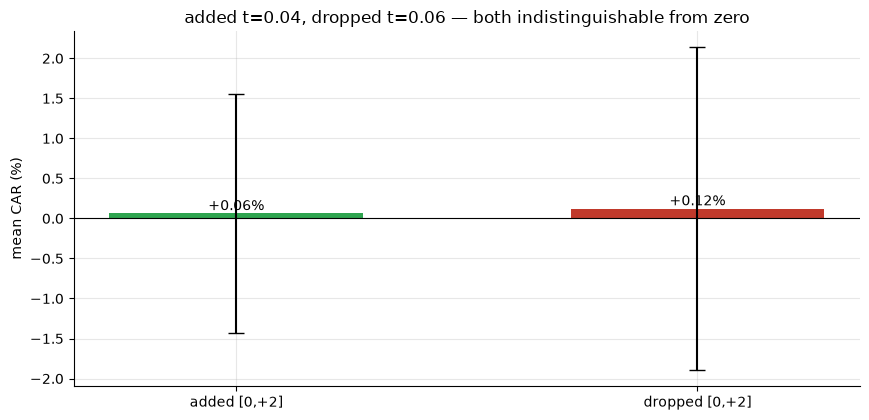

added +0.06% (t=0.04)   dropped +0.12% (t=0.06)   H1 wants added>0, H2 wants dropped<0


In [2]:
if HAVE_REAL:
    A = PANEL.loc[PANEL['added'],'car'].to_numpy(); D = PANEL.loc[~PANEL['added'],'car'].to_numpy()
    am, dm = A.mean()*100, D.mean()*100
    ase, dse = A.std(ddof=1)/np.sqrt(len(A))*100, D.std(ddof=1)/np.sqrt(len(D))*100
    at, dt = st.welch_t(A), st.welch_t(D)
else:
    am, dm, at, dt = R['added'][0], R['dropped'][0], R['added'][2], R['dropped'][2]
    ase, dse = am/max(at,1e-9), dm/max(dt,1e-9)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['added [0,+2]','dropped [0,+2]'], [am, dm], yerr=[ase, dse], capsize=6,
       color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean CAR (%)')
ax.set_title(f'added t={at:.2f}, dropped t={dt:.2f} — both indistinguishable from zero')
for i,v in enumerate([am,dm]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'added {am:+.2f}% (t={at:.2f})   dropped {dm:+.2f}% (t={dt:.2f})   H1 wants added>0, H2 wants dropped<0')

> 💡 In plain words: the debut CAR is **+0.06%** at **t = 0.04**, the exit CAR is **+0.12%** at **t = 0.06** (*positive* — the wrong sign for a penalty), and the error bars swallow both. H₁ and H₂ are both **not supported**, and survivorship only pushes the exit leg *more* positive.

### 4b · The decisive test — a placebo null sized to the event count

Draw 14 random non-event windows thousands of times; the histogram is the null for the mean debut CAR. The real pop is the green line; the *p*-value is the two-sided tail mass.

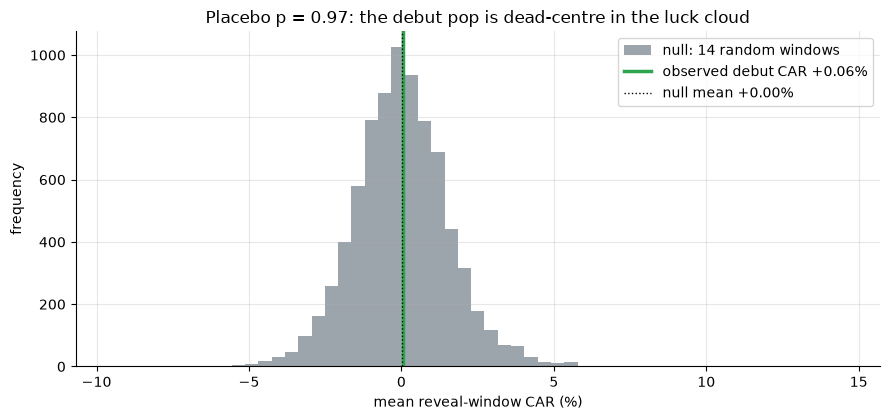

P[|random 14-window mean| >= |debut CAR|] = 0.966  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    k=int(PANEL['added'].sum())
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=k, n_draws=8000)
    obs = PANEL.loc[PANEL['added'],'car'].mean()*100; draws=null*100
    pval = st.placebo_pvalue(obs/100, null)
else:
    obs=R['added'][0]; pval=R['added_placebo_p']; rng=np.random.default_rng(751); draws=rng.normal(0,1.6,8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_added"]} random windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed debut CAR {obs:+.2f}%')
ax.axvline(np.mean(draws), c='k', ls=':', lw=1, label=f'null mean {np.mean(draws):+.2f}%')
ax.set_xlabel('mean reveal-window CAR (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the debut pop is dead-centre in the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_added"]}-window mean| >= |debut CAR|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **97%** of random 14-window draws match or beat the debut CAR in magnitude — it sits essentially *at the null mean*. A real effect would push the green line into a tail; instead it's in the bullseye. H₁ is **not supported** in the strongest possible sense.

### 4c · The reveal day + robustness — nothing, at any window

Unlike a forced CEO ouster (Study 391), where the announcement *day* really does jolt the stock, here even the un-tradable **[0,0]** instant is flat. And no window — not [0,0], not [−1,+1], not [0,+4] — pushes either bucket or the spread past *t* = 2.

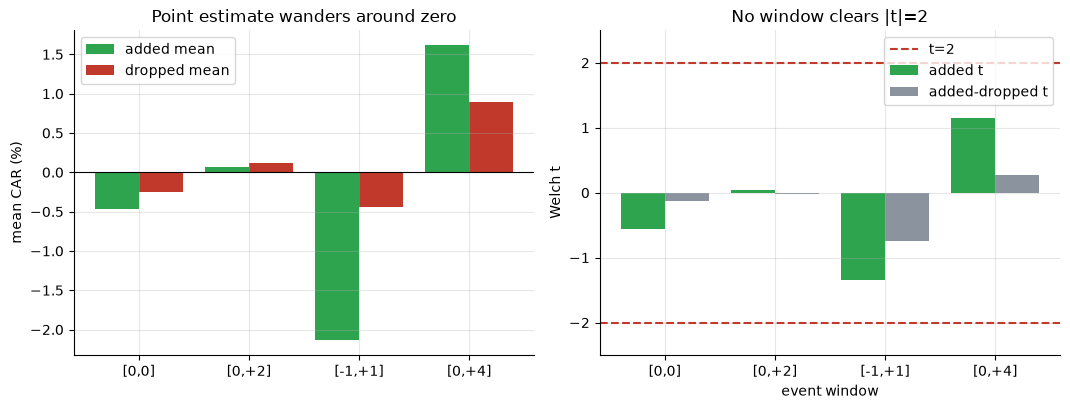

by window: [('[0,0]', -0.47, 't=-0.56', 'diff t=-0.12'), ('[0,+2]', 0.06, 't=0.04', 'diff t=-0.02'), ('[-1,+1]', -2.14, 't=-1.34', 'diff t=-0.75'), ('[0,+4]', 1.62, 't=1.15', 'diff t=0.27')]


In [4]:
rob = R['robust']
if HAVE_REAL:
    rob=[]
    for w,lab in [((0,0),'[0,0]'),((0,2),'[0,+2]'),((-1,1),'[-1,+1]'),((0,4),'[0,+4]')]:
        pw=st.car_panel(PRICES, EVENTS, window=w); sw=st.summarize(pw)
        rob.append((lab, sw['added']['mean_pct'], sw['added']['t'], sw['dropped']['mean_pct'], sw['diff_pct'], sw['diff_t']))
labs=[r[0] for r in rob]; at=[r[2] for r in rob]; dft=[r[5] for r in rob]; xx=np.arange(len(labs))
fig, (a1,a2) = plt.subplots(1, 2, figsize=(10.8, 4.2))
am=[r[1] for r in rob]; dm=[r[3] for r in rob]
a1.bar(xx-.2, am, .4, color=GREEN, label='added mean'); a1.bar(xx+.2, dm, .4, color=RED, label='dropped mean')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(xx); a1.set_xticklabels(labs); a1.set_ylabel('mean CAR (%)')
a1.set_title('Point estimate wanders around zero'); a1.legend()
a2.bar(xx-.2, at, .4, color=GREEN, label='added t'); a2.bar(xx+.2, dft, .4, color=GREY, label='added-dropped t')
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(xx); a2.set_xticklabels(labs); a2.set_ylabel('Welch t'); a2.set_xlabel('event window')
a2.set_ylim(-2.5, 2.5); a2.set_title('No window clears |t|=2'); a2.legend()
plt.tight_layout(); plt.show()
print('by window:', [(r[0], round(r[1],2), 't='+str(round(r[2],2)), 'diff t='+str(round(r[5],2))) for r in rob])

> 💡 In plain words: on the single reveal day the debuts are **-0.47%** (*t* = -0.56, placebo *p* = 0.56) — a non-event. Widen or shift the window however you like and the point estimate flips sign while the *t* stays pinned inside ±2. That sign-flipping-with-the-window behaviour is the fingerprint of **no signal**, not a fragile one.

### 4d · Faithful-engine & power control — we know the truth here

Deterministic per-event panels with a **planted** added-bucket CAR of size `car_bps`: with **`car_bps=0`** the added−dropped test must stay below *t* = 2 (a dozen events per bucket can't fake significance); with a **+500 bps** planted edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects an implausibly large effect.

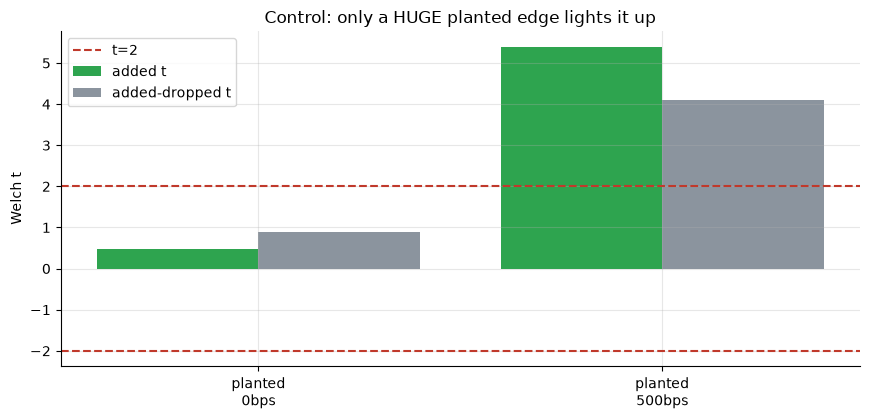

planted   0bps: added=+0.49%(t=+0.48) dropped=-0.90% added-dropped t=+0.90
planted 500bps: added=+5.49%(t=+5.40) dropped=-0.90% added-dropped t=+4.10


In [5]:
res = []
for edge in (0.0, 500.0):
    syn = data.synthetic_events(car_bps=edge, seed=751)
    a = st.summarize_bucket(syn['added_car']); d = st.summarize_bucket(syn['dropped_car'])
    dt = st.welch_t(syn['added_car'], syn['dropped_car'])
    res.append((edge, a['mean_pct'], a['t'], d['mean_pct'], dt))
labels=[f'planted\n{int(e)}bps' for e,*_ in res]; xx=np.arange(len(labels))
at=[r[2] for r in res]; dft=[r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(xx-.2, at, .4, color=GREEN, label='added t'); ax.bar(xx+.2, dft, .4, color=GREY, label='added-dropped t')
ax.axhline(2, ls='--', c=RED, label='t=2'); ax.axhline(-2, ls='--', c=RED)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t')
ax.set_title('Control: only a HUGE planted edge lights it up'); ax.legend()
plt.tight_layout(); plt.show()
for e,am,at_,dm,dt_ in res: print(f'planted {int(e):>3}bps: added={am:+.2f}%(t={at_:+.2f}) dropped={dm:+.2f}% added-dropped t={dt_:+.2f}')

> 💡 In plain words: with **no** planted edge the added−dropped *t* is **0.90** (no false positive); only the **+500 bps** plant reaches **4.10**. So the machinery is honest, and the real-tape added−dropped *t* of **-0.02** is exactly what a *true zero* looks like through a 14+12-event keyhole. The null isn't weak measurement — it's a null.

## 5 · The verdict

- **Signal `NONE`** — added **+0.06%** (*t* = 0.04), dropped **+0.12%** (*t* = 0.06), **added−dropped -0.06pp** at Welch **t = -0.02** / placebo **p = 0.97**, with a 50% win-rate in *both* buckets and a flat reveal day. No window clears *t* = 2. **Survivorship** named on this axis (worst exits delisted, biasing the drop leg up). This is a null, not a weak positive.
- **Tradability `MIRAGE`** — the most favourable window (enter +1 day, hold five) reaches only **+2.23%** at *t* = 1.39 before it's window-mined; the added−dropped spread is *t* = 0.20. Nothing to size, and costs never bind.
- **Attention effect? `NOT SUPPORTED`** — the real S&P-500 inclusion pop is a **forced-buying demand shock** (Shleifer 1986; Harris & Gurel 1986). A media ranking by already-public revenue creates no demand and reveals no news, so the prestige/attention channel has nothing to stand on — and the tape agrees.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* debut CAR have to be for a $k$-event study to detect it at $t=2$? At $k\approx 14$ you'd need several percent; the observed CAR lives far below the detection floor — and there's no drop-leg penalty to pair it with either.

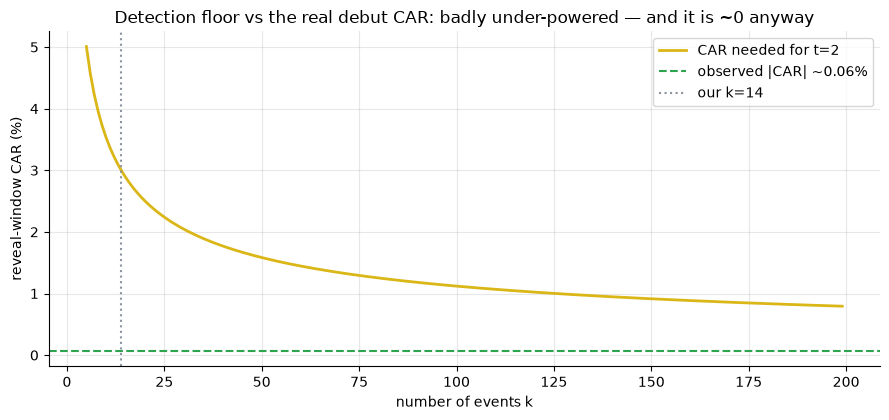

at k=14 you need ~3.0% CAR for t=2; observed ~+0.06% -> both under-powered AND ~zero


In [6]:
if HAVE_REAL:
    A = PANEL.loc[PANEL['added'],'car'].to_numpy(); sd = A.std(ddof=1); obs = A.mean()
else:
    sd = 0.06; obs = R['added'][0]/100
ks = np.arange(5, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='CAR needed for t=2')
ax.axhline(abs(obs)*100, c=GREEN, ls='--', label=f'observed |CAR| ~{abs(obs)*100:.2f}%')
ax.axvline(R['n_added'], c=GREY, ls=':', label=f"our k={R['n_added']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('reveal-window CAR (%)')
ax.set_title('Detection floor vs the real debut CAR: badly under-powered — and it is ~0 anyway'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_added'])*100
print(f'at k={R["n_added"]} you need ~{need:.1f}% CAR for t=2; observed ~{obs*100:+.2f}% -> both under-powered AND ~zero')

> 💡 In plain words: the amber curve is the **minimum detectable CAR**; the green line is what we see. They don't meet until $k$ is many times larger than the Fortune-500 calendar will ever deliver — and unlike a fragile-but-real edge, the observed CAR isn't just below the floor, it's **at zero**. There is no sizing, threshold, or cost assumption that manufactures an edge from a prestige ranking with no demand shock behind it. The romance of 'making the list' is not a catalyst the market trades on.

## 7 · Going further

- **The real one, side by side.** [Study 249 — Index-Inclusion](../249-index-inclusion/): the S&P-500 version *with* the forced-buying mechanism. The contrast is the entire lesson — **mechanism, not prestige** — and a clean natural experiment on what actually moves price at an index event.
- **The label/attention family.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) and [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model event-study engine on adjacent corporate-attention folklore, same small-sample pathology.
- **Add the corpses.** Reconstruct the bankrupt exits (J.C. Penney, Bed Bath & Beyond, Sears) from a survivorship-free feed; the drop leg may finally show a penalty — but it would be a bankruptcy, not a tradable 'fell off the list.'

*The reproducible core is offline and deterministic; the add/drop table is a hardcoded, cited labelled proxy and the exit tape is survivor-biased (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*